Cell 1: Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import kagglehub
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

Cell 2: Download and load the dataset

In [2]:
path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")
print("Dataset downloaded at:", path)

csv_files = list(Path(path).rglob("*.csv"))
print("CSV files found:", csv_files)

df = pd.read_csv(csv_files[0])
df.head()

Dataset downloaded at: C:\Users\raghu\.cache\kagglehub\datasets\nehalbirla\vehicle-dataset-from-cardekho\versions\4
CSV files found: [WindowsPath('C:/Users/raghu/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4/car data.csv'), WindowsPath('C:/Users/raghu/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4/CAR DETAILS FROM CAR DEKHO.csv'), WindowsPath('C:/Users/raghu/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4/Car details v3.csv'), WindowsPath('C:/Users/raghu/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4/car details v4.csv')]


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Cell 3: Explore the dataset

In [3]:
print("Shape:", df.shape)


Shape: (301, 9)


In [4]:
print("\nColumns:")
print(df.columns)


Columns:
Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='str')


In [5]:
print("\nInfo:")
print(df.info())


Info:
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB
None


In [6]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [7]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 2


Cell 4: Clean the dataset

In [8]:
df = df.drop_duplicates()

required_cols = [
    "Year",
    "Present_Price",
    "Kms_Driven",
    "Fuel_Type",
    "Seller_Type",
    "Transmission",
    "Owner",
    "Selling_Price"
]

df = df[required_cols]
df = df.dropna(subset=["Selling_Price"])

print("Shape after cleaning:", df.shape)
df.head()

Shape after cleaning: (299, 8)


,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Selling_Price
0,2014,5.59,27000,Petrol,Dealer,Manual,0,3.35
1,2013,9.54,43000,Diesel,Dealer,Manual,0,4.75
2,2017,9.85,6900,Petrol,Dealer,Manual,0,7.25
3,2011,4.15,5200,Petrol,Dealer,Manual,0,2.85
4,2014,6.87,42450,Diesel,Dealer,Manual,0,4.60


Cell 5: Split features and target

In [9]:
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

X.head(), y.head()

(   Year  Present_Price  Kms_Driven Fuel_Type Seller_Type Transmission  Owner
 0  2014           5.59       27000    Petrol      Dealer       Manual      0
 1  2013           9.54       43000    Diesel      Dealer       Manual      0
 2  2017           9.85        6900    Petrol      Dealer       Manual      0
 3  2011           4.15        5200    Petrol      Dealer       Manual      0
 4  2014           6.87       42450    Diesel      Dealer       Manual      0,
 0    3.35
 1    4.75
 2    7.25
 3    2.85
 4    4.60
 Name: Selling_Price, dtype: float64)

Cell 6: Prepare preprocessing

In [10]:
numeric_features = ["Year", "Present_Price", "Kms_Driven", "Owner"]
categorical_features = ["Fuel_Type", "Seller_Type", "Transmission"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Cell 7: Train the regression model

In [11]:
model = RandomForestRegressor(n_estimators=200, random_state=42)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

Cell 8: Evaluate the model

In [12]:
predictions = pipeline.predict(X_test)

r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print(f"R2 Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")

R2 Score: 0.5025
MAE: 1.5007


Cell 9: Save the trained model

In [13]:
joblib.dump(pipeline, "car_price_model.pkl")
print("Saved model to car_price_model.pkl")

Saved model to car_price_model.pkl


Cell 10: Visualize feature importance

In [14]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
1,num__Present_Price,0.902310
0,num__Year,0.071895
2,num__Kms_Driven,0.013762
10,cat__Transmission_Manual,0.004241
9,cat__Transmission_Automatic,0.003678
8,cat__Seller_Type_Individual,0.001257
6,cat__Fuel_Type_Petrol,0.001002
7,cat__Seller_Type_Dealer,0.000988
5,cat__Fuel_Type_Diesel,0.000853
3,num__Owner,0.000011


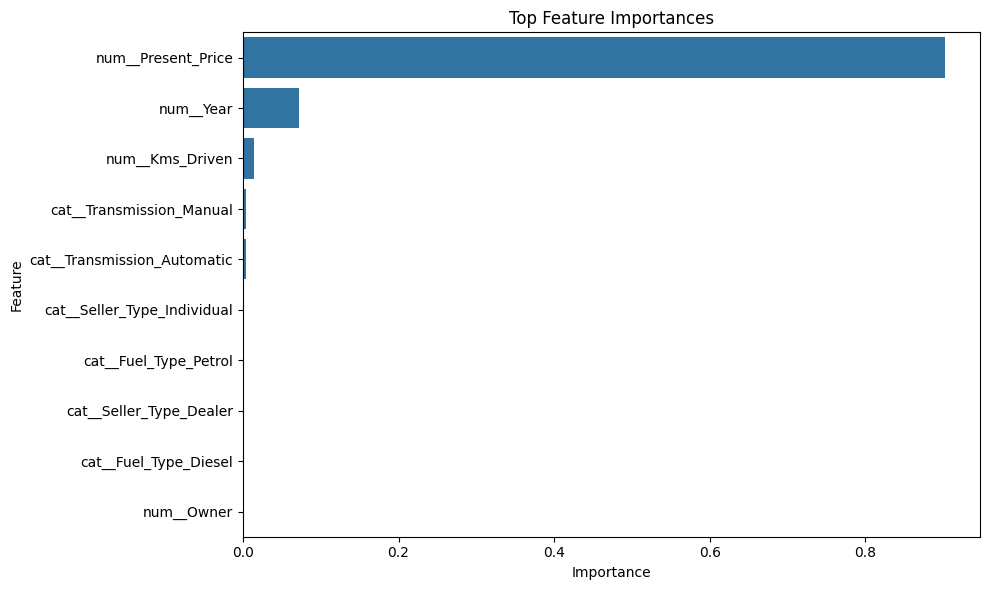

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x="Importance", y="Feature")
plt.title("Top Feature Importances")
plt.tight_layout()
plt.show()

Cell 11: Save feature importance chart

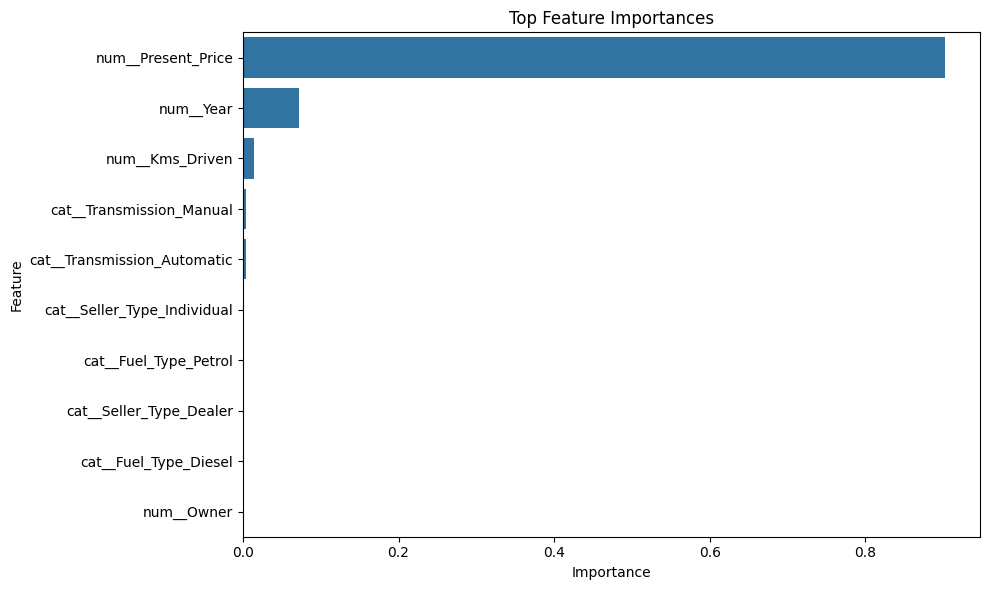

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x="Importance", y="Feature")
plt.title("Top Feature Importances")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()